# Model Building, Training & Optimization

### 🎯 Goal of This Notebook
<pre>
The goal of this notebook is to design, compile, train, and optimize a deep learning model
capable of accurately classifying crop leaf images into disease or healthy categories using Keras and TensorFlow.
</pre>
### This notebook ensures:
 - Correct model architecture selection
 - Stable training on low-resource systems
 - Overfitting control
 - Best model preservation for evaluation and deployment



## Clone Repository & Set Project Root
### 📌 Purpose
<pre>
 - To obtain the complete project structure locally for exploration and experimentation.
</pre>


In [1]:

# Clone the Repository
!git clone https://github.com/sabin74/Agriculture-Crop-Disease-Detection-Advisory-System.git



Cloning into 'Agriculture-Crop-Disease-Detection-Advisory-System'...
remote: Enumerating objects: 97172, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 97172 (delta 8), reused 22 (delta 7), pack-reused 97133 (from 3)
Receiving objects: 100% (97172/97172), 1.62 GiB | 44.90 MiB/s, done.
Resolving deltas: 100% (458/458), done.
Updating files: 100% (94786/94786), done.


In [3]:
# Set Project Root
import os
os.chdir("/kaggle/working/Agriculture-Crop-Disease-Detection-Advisory-System")
print("Current Directory: ", os.getcwd())

Current Directory:  /kaggle/working/Agriculture-Crop-Disease-Detection-Advisory-System


## Import Required Libraries
### 📌 Purpose

Load all libraries required for:

 - Model architecture construction
 - Training and optimization
 - Callback handling
 - Performance visualization

In [4]:
# Core DL libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Callbacks
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

# Utilities
import os
import sys
import yaml
import json
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

2026-01-27 07:56:55.681968: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769500616.098825      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769500616.271960      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769500617.178417      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769500617.178456      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769500617.178460      55 computation_placer.cc:177] computation placer alr

In [5]:
# Environment check
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("Python:", sys.executable)
print("GPU Available:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.19.0
Keras: 3.10.0
Python: /usr/bin/python3
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load Configuration & Path
### 📌 Purpose

Prepare the execution environment and confirm all preprocessing outputs required for model training are available.

In [6]:
# Set Project Root
PROJECT_ROOT = Path("Modeling")
CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"

if not CONFIG_PATH.exists():
    raise FileNotFoundError("config.yaml not found")

with open(CONFIG_PATH) as f:
    config = yaml.load(f, Loader=yaml.FullLoader)

IMAGE_SIZE = tuple(config["image"]["size"])
BATCH_SIZE = config["training"]["batch_size"]

print("Image Size:", IMAGE_SIZE)
print("Batch Size:", BATCH_SIZE)

Image Size: (224, 224)
Batch Size: 32


In [7]:
# Dataset paths
DATASET_ROOT = PROJECT_ROOT / "Crop Disease Dataset"
TRAIN_DIR = DATASET_ROOT / "train"
VALID_DIR = DATASET_ROOT / "valid"

print(TRAIN_DIR)
print(VALID_DIR)

Modeling/Crop Disease Dataset/train
Modeling/Crop Disease Dataset/valid


In [8]:
# Train generator
def get_train_generator(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    color_mode="rgb",
    class_mode="categorical",
    seed=42
):
    """
    Returns augmented training data generator
    """
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=25,
        zoom_range=0.2,
        horizontal_flip=True,
        brightness_range=(0.8, 1.2),
        width_shift_range=0.1,
        height_shift_range=0.1,
        fill_mode="nearest"
    )

    return train_datagen.flow_from_directory(
        directory=train_dir,
        target_size=image_size,
        batch_size=batch_size,
        color_mode=color_mode,
        class_mode=class_mode,
        shuffle=True,
        seed=seed
    )

# Valid Generator
def get_valid_generator(
    valid_dir,
    image_size=(224, 224),
    batch_size=32,
    color_mode="rgb",
    class_mode="categorical"
):
    """
    Returns validation data generator (NO augmentation)
    """
    valid_datagen = ImageDataGenerator(
        rescale=1./255
    )

    return valid_datagen.flow_from_directory(
        directory=valid_dir,
        target_size=image_size,
        batch_size=batch_size,
        color_mode=color_mode,
        class_mode=class_mode,
        shuffle=False
    )


In [9]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Build generators
train_generator = get_train_generator(
    train_dir=TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

valid_generator = get_valid_generator(
    valid_dir=VALID_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Number of classes
NUM_CLASSES = train_generator.num_classes
print("Number of Classes:", NUM_CLASSES)

Found 74880 images belonging to 13 classes.
Found 19804 images belonging to 13 classes.
Number of Classes: 13


## Choose Model Strategy
### 📌 Purpose

Select an appropriate model architecture strategy that balances:

 - Accuracy
 - Training stability
 - Hardware limitations

This decision directly impacts training time, memory usage, and final performance.

In [10]:
MODEL_STRATEGY = "Transfer Learning"
BASE_MODEL_NAME = "MobileNetV2"

print(MODEL_STRATEGY, BASE_MODEL_NAME)

Transfer Learning MobileNetV2


## Load Pretrained Base Model (Transfer Learning)
### 📌 Purpose

Leverage ImageNet-trained visual features to:

 - Reduce training time
 - Improve accuracy
 - Ensure stable learning on low-resource systems

At this stage, the pretrained model acts purely as a feature extractor.

In [11]:
# load MobileNetV2 Base Model

from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=IMAGE_SIZE + (3,)
)

base_model.trainable = False
print("Base model frozen")


I0000 00:00:1769500691.607626      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Base model frozen


In [12]:
# Verify Model Status
print(f"Model Name: {base_model.name}")
print(f"Base Model Status: {base_model.trainable}")
print(f"Model Layers: {len(base_model.layers)}")

Model Name: mobilenetv2_1.00_224
Base Model Status: False
Model Layers: 154


In [13]:
# sanity check
trainable_layers = [layer for layer in base_model.layers if layer.trainable]
frozen_layers = [layer for layer in base_model.layers if not layer.trainable]

print(f"Trainable Layers: {len(trainable_layers)}")
print(f"Frozen Layers: {len(frozen_layers)}")

Trainable Layers: 0
Frozen Layers: 154


## Build Custom Classification Head
### 📌 Purpose

Adapt the pretrained MobileNetV2 feature extractor to your crop disease dataset by adding a custom classifier head.

In [14]:
# Build Calssificaion Head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)      # stabilizes training
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)

# output layer
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="predictions"
)(x)


## Assemble Final Model
###📌 Purpose

Combine the pretrained MobileNetV2 base model with the custom classification head to form the complete end-to-end model for crop disease classification.

In [15]:
# Create final Keras Model
model = models.Model(
    inputs=base_model.input,
    outputs=outputs,
    name="CropDisease_MobileNetV2"
)

model.summary()


Model: "CropDisease_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,625,613 (10.02 MB)

 Trainable params: 365,069 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [16]:
# Save model summary
MODEL_DIR = Path("Modeling/models")
MODEL_DIR.mkdir(exist_ok=True)

with open(MODEL_DIR / "model_summary.txt", "w") as f:
    model.summary(print_fn=lambda x: f.write(x + "\n"))

In [17]:
# Sanity Check
for layer in model.layers[-6:]:
    print(f"{layer.name:30} | Trainable: {layer.trainable}")


batch_normalization            | Trainable: True
dense                          | Trainable: True
dropout                        | Trainable: True
dense_1                        | Trainable: True
dropout_1                      | Trainable: True
predictions                    | Trainable: True


## Compile the Model
### 📌 Purpose

Configure how the model learns, optimizes, and evaluates during training.

In [18]:
# compile Model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
# Check
print("Optimizer:", model.optimizer)
print("Loss Function:", model.loss)
print("Metrics:", model.metrics_names)

Optimizer: <keras.src.optimizers.adam.Adam object at 0x78ee6cd914f0>
Loss Function: categorical_crossentropy
Metrics: ['loss', 'compile_metrics']


## Define Training Callbacks
### 📌 Purpose

Improve training stability, prevent overfitting, and automatically save the best-performing model during training.

In [20]:
# Define Model Checkpoint
checkpoint_cb = ModelCheckpoint(
    filepath=MODEL_DIR / "best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# define Early Stopping
earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

# Define ReduceLROnPlateau
reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Combine Callbacks
callbacks = [checkpoint_cb, earlystop_cb, reduce_lr_cb]


## Train the Model (Initial Training)
### 📌 Purpose

Train only the custom classification head while keeping the pretrained MobileNetV2 base model frozen.

In [21]:
INITIAL_EPOCHS = 30

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30


I0000 00:00:1769500764.494175     145 service.cc:152] XLA service 0x78ee30144290 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769500764.494219     145 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1769500765.721723     145 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1769500773.186014     145 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2340/2340 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.6066 - loss: 1.3007
Epoch 1: val_loss improved from inf to 0.15442, saving model to Modeling/models/best_model.keras
2340/2340 ━━━━━━━━━━━━━━━━━━━━ 893s 375ms/step - accuracy: 0.6067 - loss: 1.3005 - val_accuracy: 0.9534 - val_loss: 0.1544 - learning_rate: 1.0000e-04
Epoch 2/30
2340/2340 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9009 - loss: 0.3075
Epoch 2: val_loss improved from 0.15442 to 0.13170, saving model to Modeling/models/best_model.keras
2340/2340 ━━━━━━━━━━━━━━━━━━━━ 859s 367ms/step - accuracy: 0.9009 - loss: 0.3075 - val_accuracy: 0.9617 - val_loss: 0.1317 - learning_rate: 1.0000e-04
Epoch 3/30
2340/2340 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9322 - loss: 0.2090
Epoch 3: val_loss improved from 0.13170 to 0.11322, saving model to Modeling/models/best_model.keras
2340/2340 ━━━━━━━━━━━━━━━━━━━━ 864s 369ms/step - accuracy: 0.9322 - loss: 0.2090 - val_accuracy: 0.9672 - val_loss: 0.1132 - learning_rate: 

In [22]:
# Available Histroy Keys
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

### Save Initial Model and History


In [23]:
# Save in keras
model.save(MODEL_DIR / "crop_disease_model_initial.keras")

# Save in h5
model.save(MODEL_DIR / "crop_disease_model_initial.h5")

In [24]:
# Save Training History
with open(MODEL_DIR / "initial_training_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

# Visualize Training Performance
📌 Purpose

Visualize training and validation metrics to:

 - Understand learning behavior
 - Detect overfitting or underfitting
 - Support model evaluation and reporting

In [25]:
# Output Directory
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [26]:
# define Plot Function
def plot_metric(metric, val_metric, title, filename):
    plt.figure(figsize=(8,5))
    plt.plot(metric, label="Train")
    plt.plot(val_metric, label="Validation")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.legend()
    plt.grid(True)
    plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

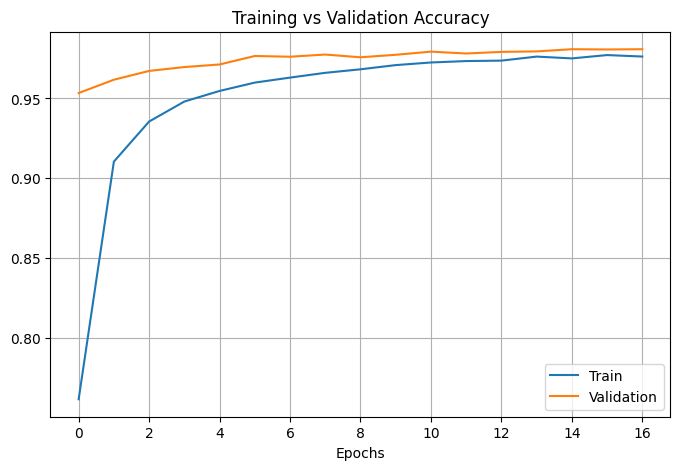

In [27]:
# Plot tTraining vs Validation Accuracy
plot_metric(
    history.history["accuracy"],
    history.history["val_accuracy"],
    "Training vs Validation Accuracy",
    "accuracy_curve.png"
)

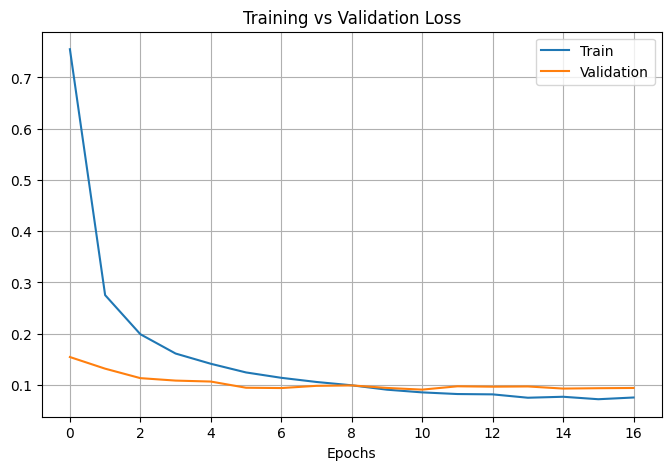

In [28]:
# Plot Training vs Validation Loss
plot_metric(
    history.history["loss"],
    history.history["val_loss"],
    "Training vs Validation Loss",
    "loss_curve.png"
)

## Fine-Tuning
### 📌 Purpose

Improve model accuracy by fine-tuning higher-level features of the pretrained MobileNetV2 base model.

In [29]:
# Fine Tuning
FINE_TUNE_AT = int(len(base_model.layers) * 0.75)

for layer in base_model.layers[FINE_TUNE_AT:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [30]:
# Continue Training
FINE_TUNE_EPOCHS = 10

fine_tune_history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10


2026-01-27 12:07:36.560811: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-27 12:07:36.757533: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2340/2340 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.9249 - loss: 0.2492
Epoch 1: val_loss improved from 0.09082 to 0.08855, saving model to Modeling/models/best_model.keras
2340/2340 ━━━━━━━━━━━━━━━━━━━━ 900s 377ms/step - accuracy: 0.9249 - loss: 0.2492 - val_accuracy: 0.9801 - val_loss: 0.0886 - learning_rate: 1.0000e-05
Epoch 2/10
2340/2340 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.9692 - loss: 0.1015
Epoch 2: val_loss improved from 0.08855 to 0.08852, saving model to Modeling/models/best_model.keras
2340/2340 ━━━━━━━━━━━━━━━━━━━━ 882s 377ms/step - accuracy: 0.9692 - loss: 0.1014 - val_accuracy: 0.9823 - val_loss: 0.0885 - learning_rate: 1.0000e-05
Epoch 3/10
2340/2340 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.9771 - loss: 0.0734
Epoch 3: val_loss improved from 0.08852 to 0.06375, saving model to Modeling/models/best_model.keras
2340/2340 ━━━━━━━━━━━━━━━━━━━━ 916s 391ms/step - accuracy: 0.9771 - loss: 0.0734 - val_accuracy: 0.9878 - val_loss: 0.0637 - learning_ra

## Save Final Trained Model
### 📌 Purpose

Preserve the fully trained model for:

 - Evaluation
 - Deployment
 - Future inference without retraining

In [31]:
# Save in keras
model.save(MODEL_DIR / "crop_disease_model_final.keras")

# Save in h5
model.save(MODEL_DIR / "crop_disease_model_final.h5")

In [32]:
# Save Training History
with open(MODEL_DIR / "fine_tuned_training_history.pkl", "wb") as f:
    pickle.dump(fine_tune_history.history,f)
